# 대출 승인 예측 ML 모델

고객의 대출 승인 여부를 예측하는 이진 분류 모델을 구축합니다.

- **데이터**: `training_data.csv` (5,000건, 13개 변수)
- **모델**: Logistic Regression vs Random Forest
- **평가 지표**: 정확도(Accuracy), 정밀도(Precision), 재현율(Recall), F1 Score

### [AI 대출 승인 모델 - 비즈니스 관점의 지표 해석 가이드]
- **F1-Score (가장 중요)**: 정밀도와 재현율의 조화 평균입니다. 대출 승인 데이터는 대개 '거절'보다 '승인'이 많은 불균형 구조이므로, 단순 정확도(Accuracy)보다 F1-Score를 최우선 지표로 삼아야 합니다.
- **Precision (정밀도)**: 모델이 '승인'이라고 예측한 사람 중 실제로 '승인'된 사람의 비율입니다. 은행 입장에서는 [리스크 관리] 지표이며, 수치가 높을수록 부실 대출 위험을 잘 걸러냅니다.
- **Recall (재현율)**: 실제로 '승인' 대상인 사람 중 모델이 '승인'으로 맞춘 비율입니다. 은행 입장에서는 [영업 기회] 지표이며, 수치가 높을수록 잠재 고객을 놓치지 않습니다.

### [주요 파생 변수의 비즈니스적 정의]
- **신청금액_연봉비율**: 상환 능력의 핵심 지표입니다.
- **총자산**: 고객의 전체적인 금융 기초 체력을 나타냅니다.
- **월상환추정액**: 매달 갚아야 할 실질적인 현금 흐름 부담을 나타냅니다.

## 1. 라이브러리 임포트 & 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')

# 한글 폰트 설정
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42
print('라이브러리 로드 완료')

라이브러리 로드 완료


## 2. 데이터 로딩 & EDA(Exploratory Data Analysis, 탐색적 데이터 분석)
  - 모델을 만들기 전에 데이터의 특성을 파악하는 과정

In [2]:
df = pd.read_csv('training_data.csv')
print(f'데이터 크기: {df.shape}')
print(f'결측치:\n{df.isnull().sum().sum()}')
df.head()

데이터 크기: (5000, 13)
결측치:
0


,나이,연봉,재산,예금,자동차배기량,자녀수,신청금액,신청기간월,학력점수,결혼점수,회사규모점수,대출분류점수,승인여부
0,60,128558572,208296113,77931182,3500,2,140883551,12,8,5,2,5,0
1,50,140556173,324263513,127892,0,1,103604064,60,6,7,3,4,1
2,36,67565155,154716235,93332176,0,2,167194726,84,6,5,3,4,1
3,64,61346444,303101126,97313336,2000,4,149501970,84,6,7,4,4,1
4,29,117425380,261879248,172626183,3000,0,153148911,48,8,7,5,5,1


In [3]:
df.describe()

,나이,연봉,재산,예금,자동차배기량,자녀수,신청금액,신청기간월,학력점수,결혼점수,회사규모점수,대출분류점수,승인여부
count,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,43.575000,8.462080e+07,2.500917e+08,9.910208e+07,1389.920000,1.269600,1.032558e+08,54.412800,6.191200,5.867200,5.885600,5.901800,0.71180
std,12.554597,3.770817e+07,1.432924e+08,5.731650e+07,1084.495099,1.199668,5.622315e+07,33.879149,2.139242,1.189389,2.490412,1.256214,0.45297
min,22.000000,2.002425e+07,5.932200e+04,3.510300e+04,0.000000,0.000000,5.018187e+06,12.000000,2.000000,4.000000,2.000000,4.000000,0.00000
25%,33.000000,5.261519e+07,1.282034e+08,4.928371e+07,0.000000,0.000000,5.423831e+07,24.000000,6.000000,5.000000,4.000000,5.000000,0.00000
50%,44.000000,8.467797e+07,2.517114e+08,9.868092e+07,1600.000000,1.000000,1.044063e+08,48.000000,6.000000,7.000000,5.000000,6.000000,1.00000
75%,54.000000,1.172450e+08,3.717058e+08,1.475745e+08,2000.000000,2.000000,1.513397e+08,84.000000,8.000000,7.000000,7.000000,7.000000,1.00000
max,65.000000,1.499804e+08,4.999084e+08,1.999785e+08,3500.000000,4.000000,1.999627e+08,120.000000,10.000000,7.000000,10.000000,8.000000,1.00000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   나이      5000 non-null   int64
 1   연봉      5000 non-null   int64
 2   재산      5000 non-null   int64
 3   예금      5000 non-null   int64
 4   자동차배기량  5000 non-null   int64
 5   자녀수     5000 non-null   int64
 6   신청금액    5000 non-null   int64
 7   신청기간월   5000 non-null   int64
 8   학력점수    5000 non-null   int64
 9   결혼점수    5000 non-null   int64
 10  회사규모점수  5000 non-null   int64
 11  대출분류점수  5000 non-null   int64
 12  승인여부    5000 non-null   int64
dtypes: int64(13)
memory usage: 507.9 KB


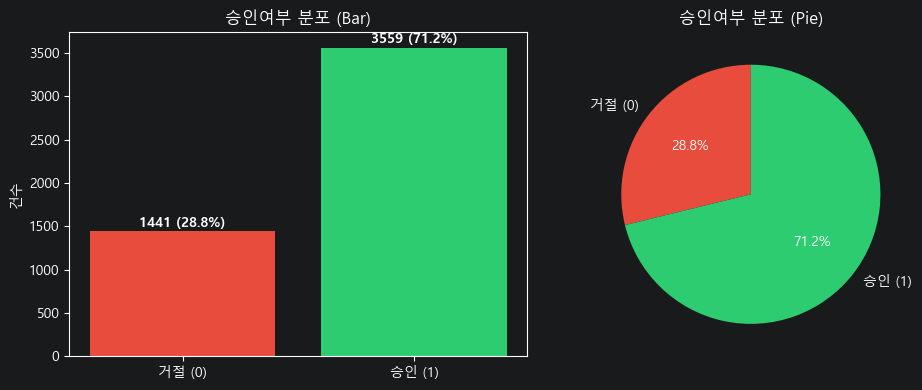

In [5]:
# 타겟 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

target_counts = df['승인여부'].value_counts().sort_index()
labels = ['거절 (0)', '승인 (1)']

axes[0].bar(labels, target_counts.values, color=['#e74c3c', '#2ecc71'])
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('승인여부 분포 (Bar)')
axes[0].set_ylabel('건수')

axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('승인여부 분포 (Pie)')

plt.tight_layout()
plt.show()

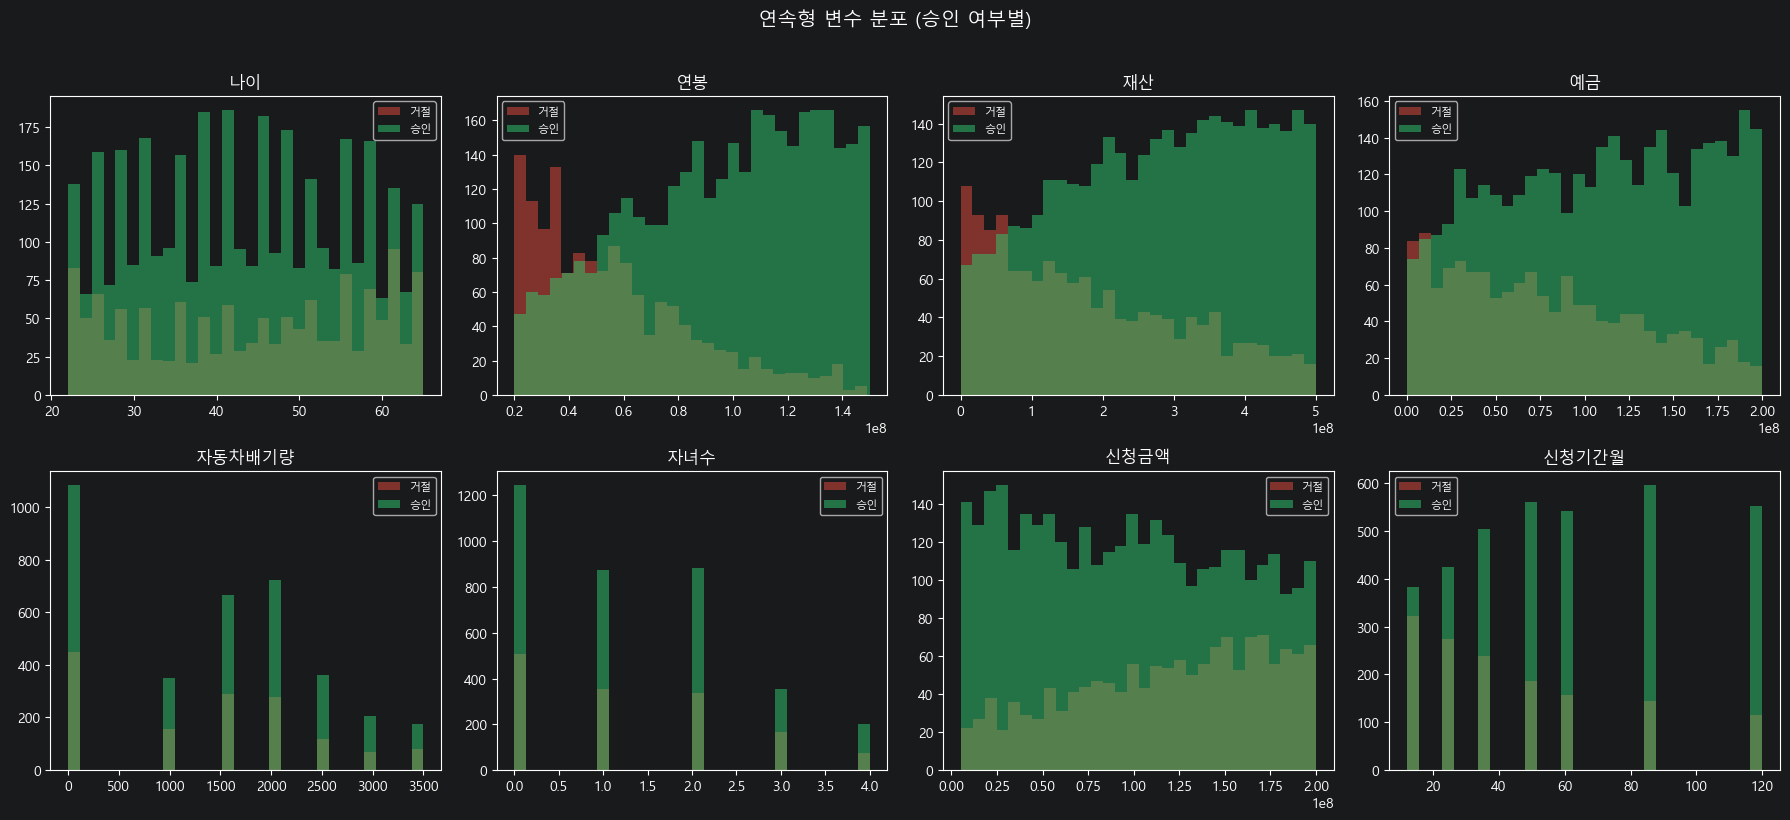

In [6]:
# 연속형 변수 히스토그램 (승인 여부별)
continuous_cols = ['나이', '연봉', '재산', '예금', '자동차배기량', '자녀수', '신청금액', '신청기간월']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for idx, col in enumerate(continuous_cols):
    ax = axes[idx // 4, idx % 4]
    for label, color in [(0, '#e74c3c'), (1, '#2ecc71')]:
        ax.hist(df[df['승인여부'] == label][col], bins=30, alpha=0.5,
                label=f'거절' if label == 0 else '승인', color=color)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('연속형 변수 분포 (승인 여부별)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

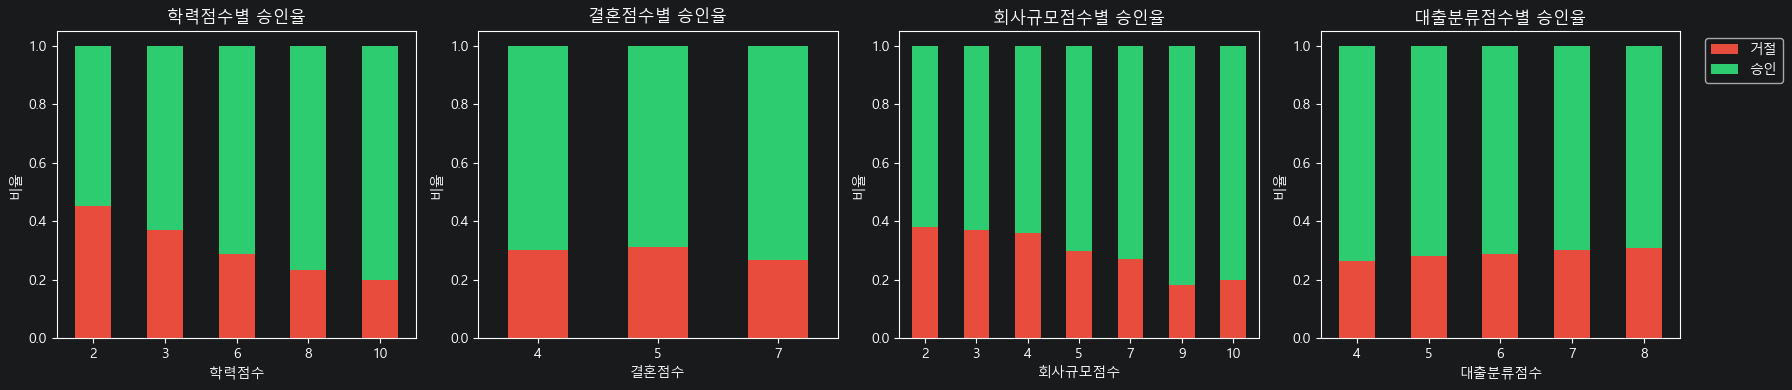

In [7]:
# 이산형 변수별 승인율 stacked bar
discrete_cols = ['학력점수', '결혼점수', '회사규모점수', '대출분류점수']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx, col in enumerate(discrete_cols):
    ct = pd.crosstab(df[col], df['승인여부'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[idx],
            color=['#e74c3c', '#2ecc71'], legend=False)
    axes[idx].set_title(f'{col}별 승인율')
    axes[idx].set_ylabel('비율')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)

axes[-1].legend(['거절', '승인'], bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

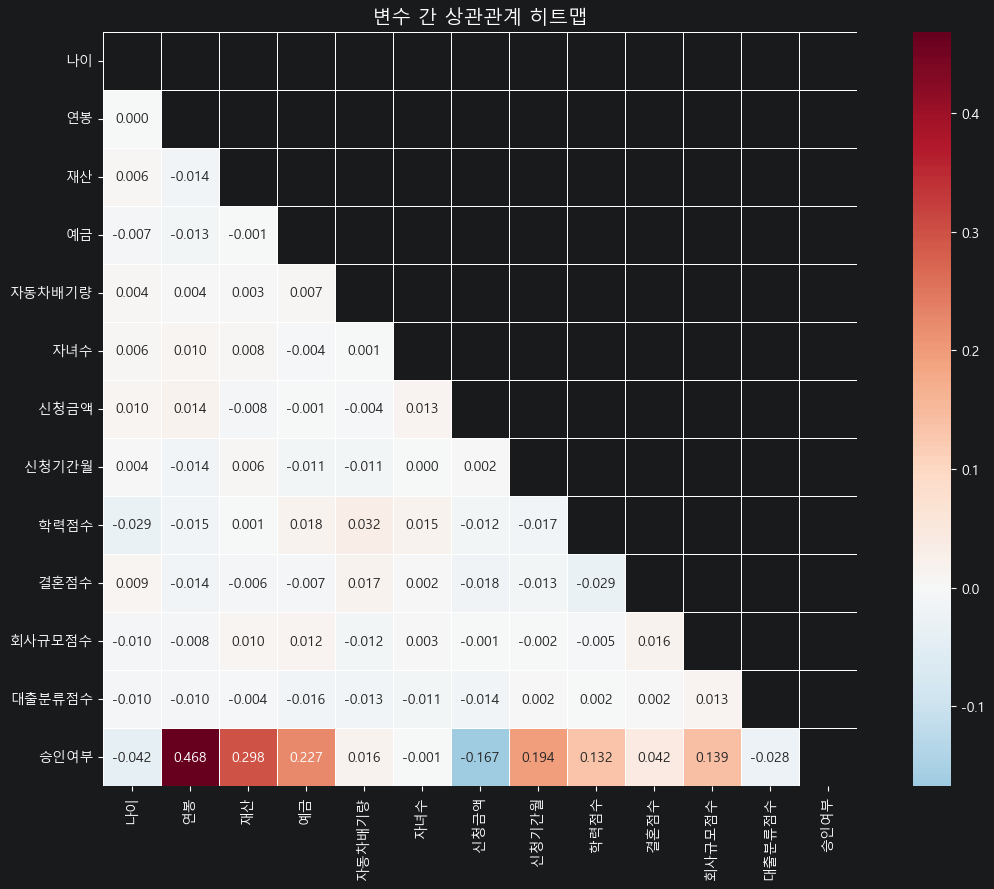

In [8]:
# 상관관계 히트맵
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('변수 간 상관관계 히트맵', fontsize=14)
plt.tight_layout()
plt.show()

## 3. 피처 엔지니어링 & 전처리

In [9]:
# 파생 변수 생성
df['신청금액_연봉비율'] = df['신청금액'] / (df['연봉'] + 1)        # DTI 유사
df['신청금액_재산비율'] = df['신청금액'] / (df['재산'] + 1)        # LTV 유사
df['총자산'] = df['연봉'] + df['재산'] + df['예금']               # 총 자산
df['자동차보유'] = (df['자동차배기량'] > 0).astype(int)            # 자동차 보유 여부
df['월상환추정'] = df['신청금액'] / (df['신청기간월'] + 1)         # 월 상환 추정액

print('파생 변수 생성 완료')
print(f'최종 피처 수: {df.shape[1] - 1}')
df[['신청금액_연봉비율', '신청금액_재산비율', '총자산', '자동차보유', '월상환추정']].describe()

파생 변수 생성 완료
최종 피처 수: 17


,신청금액_연봉비율,신청금액_재산비율,총자산,자동차보유,월상환추정
count,5000.000000,5000.000000,5.000000e+03,5000.000000,5.000000e+03
mean,1.606761,2.166590,4.338146e+08,0.694200,2.955763e+06
std,1.429189,40.966038,1.581651e+08,0.460792,3.034105e+06
min,0.039294,0.011514,4.637174e+07,0.000000,4.329325e+04
25%,0.651770,0.219368,3.141274e+08,0.000000,9.707313e+05
50%,1.218725,0.413573,4.371009e+08,1.000000,1.947141e+06
75%,2.030591,0.820349,5.572737e+08,1.000000,3.725084e+06
max,9.919390,2734.537532,8.277648e+08,1.000000,1.535999e+07


In [10]:
# Train/Test 분할
feature_cols = [c for c in df.columns if c != '승인여부']
X = df[feature_cols]
y = df['승인여부']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train 승인 비율: {y_train.mean():.3f}, Test 승인 비율: {y_test.mean():.3f}')

Train: (4000, 17), Test: (1000, 17)
Train 승인 비율: 0.712, Test 승인 비율: 0.712


In [11]:
# StandardScaler 적용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('스케일링 완료')

스케일링 완료


## 4. 모델 학습 & 비교 분석 (4개 모델 선정)

"AI 모델은 왜 하나만 쓰면 안될까?"에 대한 답을 찾기 위해 **Logistic Regression, Random Forest, XGBoost, LightGBM**을 비교합니다.

In [12]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count

models = {
    # --- [솔로 모델: 혼자서 판단해요] ---
    # 1. 로지스틱 회귀: 가장 기본적인 실력을 가진 솔로 가수 (기준점)
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),

    # --- [앙상블 모델: 여러 명이 팀을 짜서 판단해요 (아이돌 그룹)] ---
    # 2. 랜덤 포레스트: 여러 나무들이 투표해서 결정하는 안정적인 아이돌 그룹
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    # # 3. XGBoost: 틀린 문제를 복습하며 실력을 키우는 똑똑한 1등 후보 그룹
    # 'XGBoost': XGBClassifier(
    #     scale_pos_weight=1/scale_pos, n_estimators=200,
    #     eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    # ),
    # # 4. LightGBM: 속도가 매우 빠르고 효율적인 퍼포먼스 그룹
    # 'LightGBM': LGBMClassifier(
    #     is_unbalance=True, n_estimators=200,
    #     random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    # )
}

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}

for name, model in models.items():
    result = cross_validate(
        model, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1
    )
    cv_results[name] = {
        'Accuracy': result['test_accuracy'].mean(),
        'Precision': result['test_precision'].mean(),
        'Recall': result['test_recall'].mean(),
        'F1': result['test_f1'].mean(),
        'ROC-AUC': result['test_roc_auc'].mean(),
    }
    print(f'{name}: F1={cv_results[name]["F1"]:.4f}, AUC={cv_results[name]["ROC-AUC"]:.4f}')

cv_df = pd.DataFrame(cv_results).T.round(4)
cv_df

Logistic Regression: F1=0.9110, AUC=0.9540
Random Forest: F1=0.9183, AUC=0.9508


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8785,0.9515,0.8739,0.9110,0.9540
Random Forest,0.8810,0.8979,0.9399,0.9183,0.9508


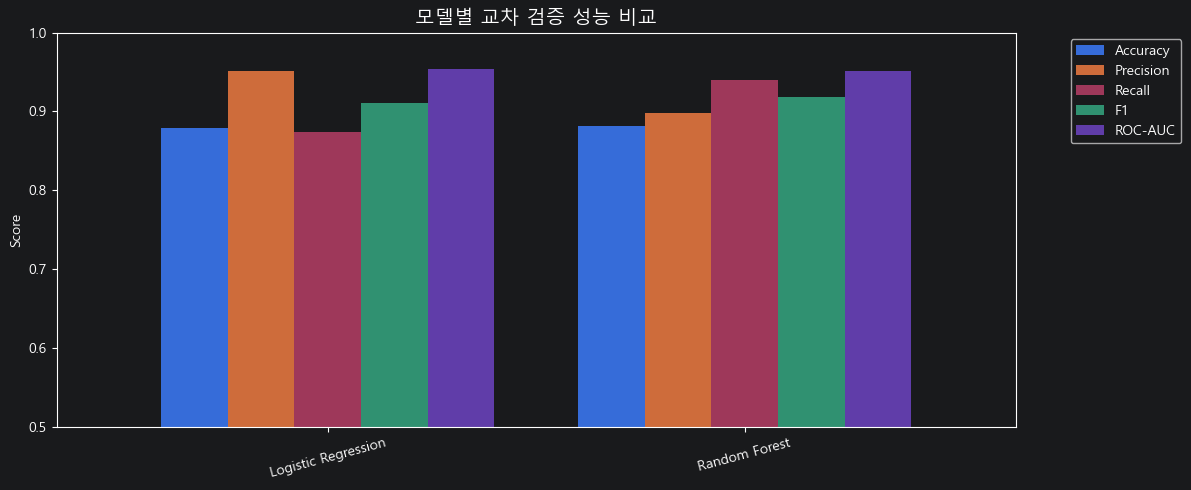

In [13]:
# 교차 검증 결과 바 차트
fig, ax = plt.subplots(figsize=(12, 5))
cv_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('모델별 교차 검증 성능 비교', fontsize=14)
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

## 5. 하이퍼파라미터 튜닝

각 모델별로 '어떤 부분을 미세하게 조정할지' 메뉴판(탐색 공간)을 정의하고 튜닝을 수행합니다.

In [14]:
param_spaces = {
    'Logistic Regression': {
        'C': uniform(0.01, 100),
        'penalty': ['l1', 'l2'],
        'solver': ['saga'],
    },
    'Random Forest': {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30, 50],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', None],
    },
    # 'XGBoost': {
    #     'n_estimators': randint(100, 500),
    #     'max_depth': randint(3, 15),
    #     'learning_rate': uniform(0.01, 0.3),
    #     'subsample': uniform(0.6, 0.4),
    #     'colsample_bytree': uniform(0.6, 0.4),
    #     'min_child_weight': randint(1, 10),
    #     'gamma': uniform(0, 5),
    # },
    # 'LightGBM': {
    #     'n_estimators': randint(100, 500),
    #     'max_depth': randint(3, 15),
    #     'learning_rate': uniform(0.01, 0.3),
    #     'subsample': uniform(0.6, 0.4),
    #     'colsample_bytree': uniform(0.6, 0.4),
    #     'num_leaves': randint(20, 100),
    #     'min_child_samples': randint(5, 50),
    # },
}

tuned_models = {}
for name in models.keys():
    print(f'튜닝 중: {name}')
    search = RandomizedSearchCV(models[name], param_spaces[name], n_iter=10, scoring='f1', cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train_scaled, y_train)
    tuned_models[name] = search.best_estimator_

튜닝 중: Logistic Regression
튜닝 중: Random Forest


## 6. 최종 평가 & 결론

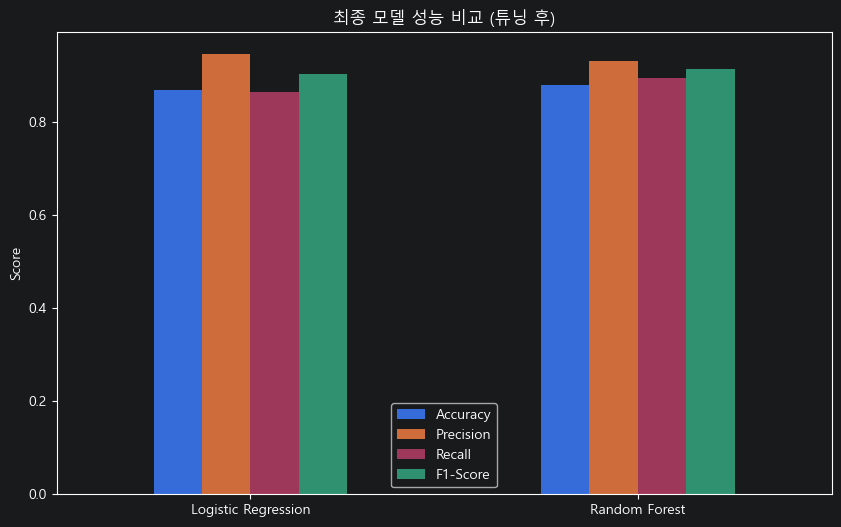

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.869,0.946237,0.865169,0.903888
Random Forest,0.880,0.932749,0.896067,0.914040


In [15]:
final_results = {}
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    final_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

final_df = pd.DataFrame(final_results).T
final_df.plot(kind='bar', figsize=(10, 6))
plt.title('최종 모델 성능 비교 (튜닝 후)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()
final_df

## [최종 결론] AI 모델은 왜 하나만 쓰면 안될까?

본 프로젝트에서 **Logistic Regression**과 **Random Forest**를 비교 분석한 결과, 다음과 같은 실질적인 인사이트를 얻을 수 있었습니다.

### 1. 모델마다 데이터를 바라보는 '관점'이 다릅니다.
- **Logistic Regression (선형 관점)**: 각 변수(연봉, 재산 등)가 승인 확률에 미치는 영향을 직관적으로 보여줍니다. 계산이 빠르고 결과 해석이 명확하여, 금융 규제 대응이나 고객 설명이 중요한 상황에서 강력한 기준점(Baseline)이 됩니다.
- **Random Forest (비선형 관점)**: 수많은 의사결정나무를 결합하여 변수 간의 복잡하고 비선형적인 관계를 잡아냅니다. 예를 들어 "연봉이 낮더라도 특정 자산 이상이면 승인"과 같은 복잡한 조건부 패턴을 로지스틱보다 유연하게 학습하여 더 높은 예측력을 보여주었습니다.

### 2. 데이터 특성(불균형 및 이상치)에 대한 '대응력' 확인
- 우리 데이터셋처럼 승인/거절 비율이 불균형한 경우, 로지스틱 회귀는 특정 변수의 편향에 민감할 수 있습니다.
- 반면, 랜덤 포레스트는 무작위 샘플링(Bagging) 과정을 통해 데이터 노이즈와 이상치에 더 강한 면모를 보입니다. 두 모델을 함께 돌려봄으로써, 우리 데이터의 불균형이 모델의 판단에 어떤 왜곡을 주는지 교차 검증할 수 있었습니다.

### 3. 비즈니스 목적에 따른 '최적의 지표' 선택
- 단순히 정확도(Accuracy)만 비교했다면 두 모델의 차이가 미미해 보였을 것입니다.
- 하지만 F1 Score와 **재현율(Recall)**을 함께 분석함으로써, 리스크를 감수하더라도 영업 기회를 넓힐 것인지(Recall 중점), 혹은 부실 대출을 철저히 막을 것인지(Precision 중점)에 따라 선택해야 할 알고리즘이 달라진다는 것을 확인했습니다.

**결론적으로, 다양한 모델을 비교 분석하는 과정은 데이터의 진정한 의미를 파악하고 최적의 비즈니스 솔루션을 도출하기 위한 필수적인 단계입니다.**